In [1]:
import torch
from tqdm import tqdm
from scipy.ndimage.filters import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch.utils.data.sampler import Sampler
from torchvision import transforms
from PIL import Image
import time
from IPython.display import clear_output

import lovely_tensors as lt
lt.monkey_patch()

# Dummy class to store arguments
class Dummy():
    pass


# Function that opens image from disk, normalizes it and converts to tensor
read_tensor = transforms.Compose([
    lambda x: Image.open(x),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
    lambda x: torch.unsqueeze(x, 0)
])


# Plots image from tensor
def tensor_imshow(inp, title=None, **kwargs):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Mean and std for ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp, **kwargs)
    if title is not None:
        plt.title(title)


# Image preprocessing function
preprocess = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                # Normalization for ImageNet
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])


# Sampler for pytorch loader. Given range r loader will only
# return dataset[r] instead of whole dataset.
class RangeSampler(Sampler):
    def __init__(self, r):
        self.r = r

    def __iter__(self):
        return iter(self.r)

    def __len__(self):
        return len(self.r)


/tmp/ipykernel_2967399/2960153348.py:3: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
import copy
from affex.data import get_dataloaders


PROMPT_IMAGES = [
    # 'frame0009_2.png',
    'frame0021_2.png',
    "frame0033_3.png",
    'frame0034_1.png',
    'frame0048_0.png',
]

PASCAL_NAME = "val_pascal5i"
PASCAL_PARAMS = {
    "name": "pascal",
    "data_dir": "data/pascal",
    "split": "val",
    "val_fold_idx": 3,
    "n_folds": 4,
    "n_shots": 2,
    "n_ways": 1,
    "do_subsample": False,
    "val_num_samples": 100,
    "ignore_borders": True,
    "maintain_gt_shape": False,
}

parameters = {
    "dataloader": {
        "num_workers": 0,
        "possible_batch_example_nums": [[1, 2, 4]],
        "val_possible_batch_example_nums": [[1, 1]],
        },
    "dataset": {
        "preprocess": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
            "image_size": 384,
        },
        "datasets": {
            PASCAL_NAME: PASCAL_PARAMS,
        },
    },
    "model": {
        "name": "dcama",
        "backbone": "swin",
        # "backbone_checkpoint": "checkpoints/swin_base_patch4_window12_384.pth",
        "model_checkpoint": "checkpoints/swin_fold0_pascal_modcross_soft.pt",
        # 'model_checkpoint': "checkpoints/f4z7ghu7.pt",
        "concat_support": True,
        "image_size": 384,
    }
}

def get_data(n_ways, n_shots, image_size):
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_ways"] = n_ways
    parameters["dataset"]["datasets"][PASCAL_NAME]["n_shots"] = n_shots
    parameters["dataset"]["datasets"][PASCAL_NAME]["image_size"] = image_size
    parameters["dataset"]["preprocess"]["image_size"] = image_size
    
    _, val, _ = get_dataloaders(
        copy.deepcopy(parameters["dataset"]),
        copy.deepcopy(parameters["dataloader"]),
        num_processes=1,
    )
    return val[PASCAL_NAME]

/home/pasquale/projects/AffinityExplainer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cuda_device_count = torch.cuda.device_count()
cuda_device_ids = list(range(cuda_device_count))
print("CUDA device IDs:", cuda_device_ids)

CUDA device IDs: [0, 1, 2]


In [4]:
from affex.models import build_model_preconfigured

model = "dcama"
device = torch.device("cuda:2")
n_shots = 2
n_ways = 1
use_pe = True

model, image_size = build_model_preconfigured(model_name=model, use_pe=use_pe, n_shots=n_shots)
model.to(device)
model.eval()

Using pe from state_dict


DCAMAMultiClass(
  (feature_extractor): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        dim=128, input_resolution=(96, 96), depth=2
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            dim=128, input_resolution=(96, 96), num_heads=4, window_size=12, shift_size=0, mlp_ratio=4.0
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              dim=128, window_size=(12, 12), num_heads=4
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax)

In [5]:
data = get_data(n_ways, n_shots, image_size)

WARNING [06-16 17:51:48] [pascal] load_embeddings is not specified. Assuming load_embeddings=False.


Loading image filenames from val...


Loading annotations...: 100%|██████████| 1449/1449 [00:02<00:00, 607.09it/s]


In [6]:
batch = next(iter(data))

In [7]:
from affex.substitution import Substitutor


batch, dataset_name  = batch

substitutor = Substitutor(substitute=False)
substitutor.reset(batch=batch)
batch = next(substitutor)

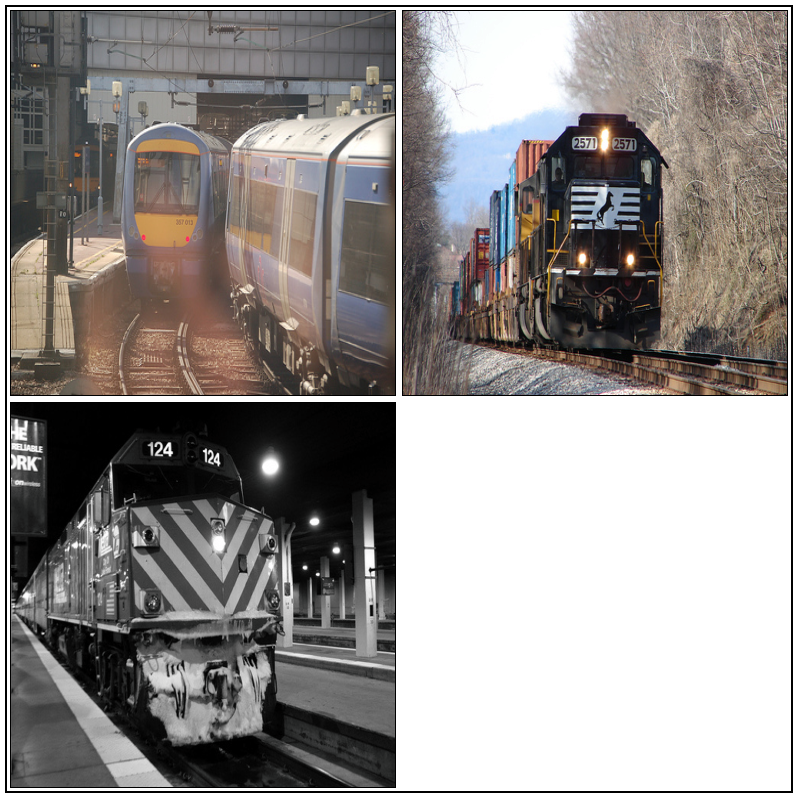

In [8]:
from affex.data.utils import BatchKeys
from affex.utils.segmentation import unnormalize

input_dict, gt = batch
unnormalize(input_dict[BatchKeys.IMAGES]).rgb

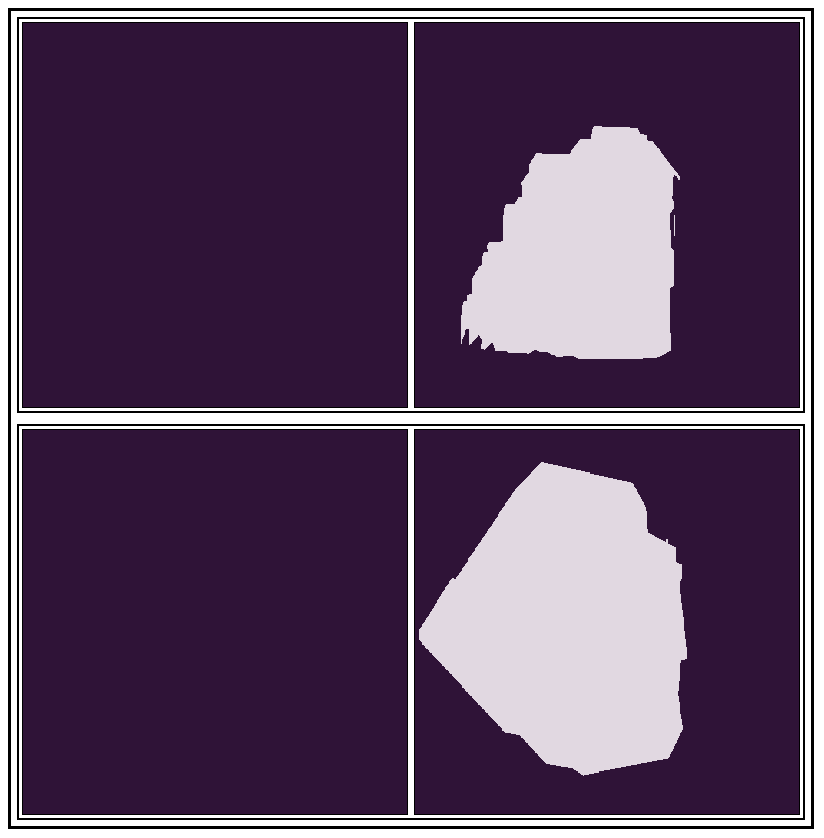

In [9]:
input_dict[BatchKeys.PROMPT_MASKS].chans

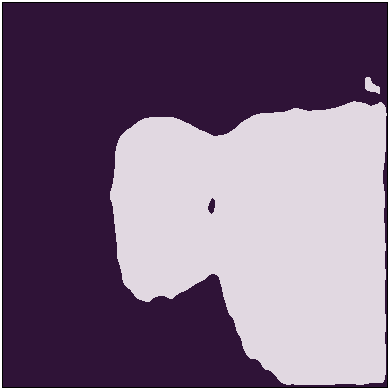

In [10]:
from affex.explainer import AffinityExplainer, get_explanation_mask

explainer = AffinityExplainer(
    model=model
)

from affex.utils.utils import ResultDict, to_device

import torch.nn.functional as F

input_dict = to_device(input_dict, device)
target_shape = input_dict[BatchKeys.IMAGES][:, 0].shape[2:]

with torch.no_grad():
    result = model(input_dict, postprocess=False)

logits = F.interpolate(
            result[ResultDict.LOGITS],
            size=target_shape,
            mode="bilinear",
            align_corners=False,
            antialias=False,
        ).argmax(dim=1)
explanation_mask = get_explanation_mask(input_dict, gt, result, target_shape, "logits")
logits.chans

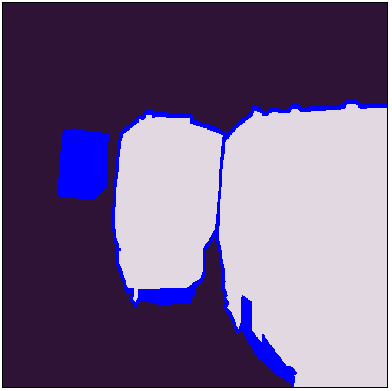

In [11]:
gt.chans

In [12]:
explanation = explainer.explain(
    input_dict=input_dict,
    explanation_mask=explanation_mask,
    explanation_size=target_shape,
)

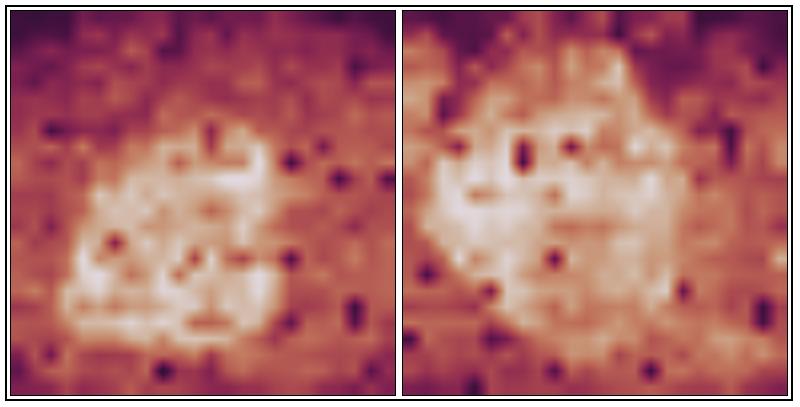

In [13]:
explanation = explanation[0]
explanation.chans

In [14]:
from affex.metrics import FSSCausalMetric


mode = 'ins'  # 'del' or 'ins'
steps_1 = 1_000  # Number of pixels to change per step
steps_2 = 10_000

tsteps_1 = 0.05

fssmetric = FSSCausalMetric(model, mode, step=steps_1, substrate_fn="zero")
xauc_1 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

fssmetric = FSSCausalMetric(model, mode, step=steps_2, substrate_fn="zero")
xauc_2 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

fssmetric = FSSCausalMetric(model, mode, threshold_step=tsteps_1, substrate_fn="zero")
xauc_3 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

Inserting pixels: 100%|██████████| 20/20 [00:01<00:00, 10.05it/s]


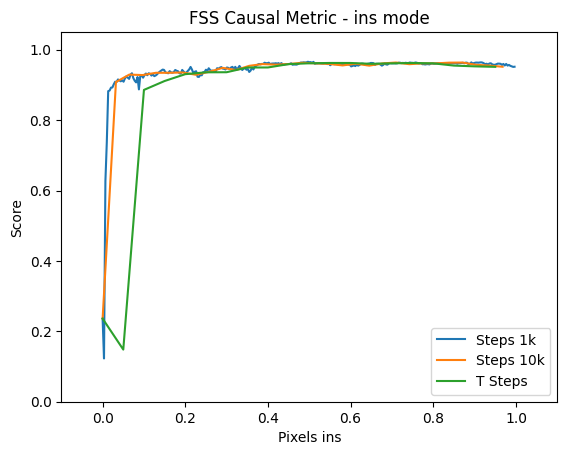

In [15]:
scores_1 = xauc_1['scores']
scores_2 = xauc_2['scores']
scores_3 = xauc_3['scores']

batch_element = 0  # Index of the batch element to plot

# Plot scores
plt.plot(np.arange(scores_1.shape[0]) / scores_1.shape[0], scores_1[:, batch_element], label='Steps 1k')
plt.plot(np.arange(scores_2.shape[0]) / scores_2.shape[0], scores_2[:, batch_element], label='Steps 10k')
plt.plot(np.arange(scores_3.shape[0]) / scores_3.shape[0], scores_3[:, batch_element], label='T Steps')
plt.title(f'FSS Causal Metric - {mode} mode')

# plt.fill_between(np.arange(scores.shape[0]) / scores.shape[0], 0, scores[:, batch_element], alpha=0.4)
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.05)
plt.xlabel(f'Pixels {mode}')
plt.ylabel('Score')
plt.legend()
plt.show()

In [17]:
from affex.metrics import FSSCausalMetric


mode = 'del'  # 'del' or 'ins'
steps_1 = 1_000  # Number of pixels to change per step
steps_2 = 10_000

tsteps_1 = 0.05

fssmetric = FSSCausalMetric(model, mode, step=steps_1, substrate_fn="zero")
xauc_1 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

fssmetric = FSSCausalMetric(model, mode, step=steps_2, substrate_fn="zero")
xauc_2 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

fssmetric = FSSCausalMetric(model, mode, threshold_step=tsteps_1, substrate_fn="zero")
xauc_3 = fssmetric.evaluate(input_dict, explanation, explanation_mask)

Deleting  pixels: 100%|██████████| 20/20 [00:01<00:00, 10.56it/s]


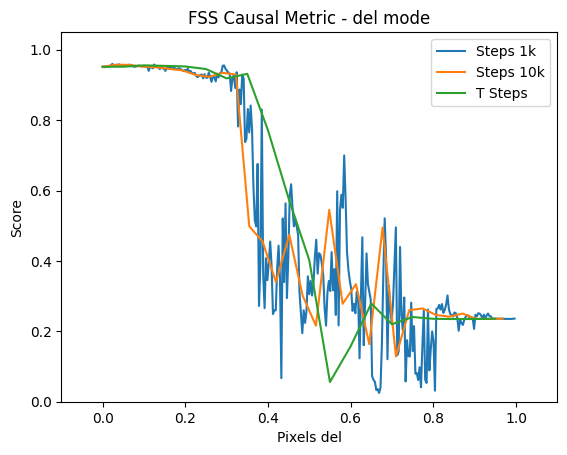

In [18]:
scores_1 = xauc_1['scores']
scores_2 = xauc_2['scores']
scores_3 = xauc_3['scores']

batch_element = 0  # Index of the batch element to plot

# Plot scores
plt.plot(np.arange(scores_1.shape[0]) / scores_1.shape[0], scores_1[:, batch_element], label='Steps 1k')
plt.plot(np.arange(scores_2.shape[0]) / scores_2.shape[0], scores_2[:, batch_element], label='Steps 10k')
plt.plot(np.arange(scores_3.shape[0]) / scores_3.shape[0], scores_3[:, batch_element], label='T Steps')
plt.title(f'FSS Causal Metric - {mode} mode')

# plt.fill_between(np.arange(scores.shape[0]) / scores.shape[0], 0, scores[:, batch_element], alpha=0.4)
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.05)
plt.xlabel(f'Pixels {mode}')
plt.ylabel('Score')
plt.legend()
plt.show()